# Simulated Annealing — Travelling Salesman Problem
This notebook walks through the algorithm step by step with visualizations at each stage.

In [35]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#0d1117',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#8b949e',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'grid.color':       '#21262d',
    'grid.linewidth':   0.6,
    'font.family':      'monospace',
})

print('Libraries loaded ✓')

Libraries loaded ✓


## 1 · Generate Cities

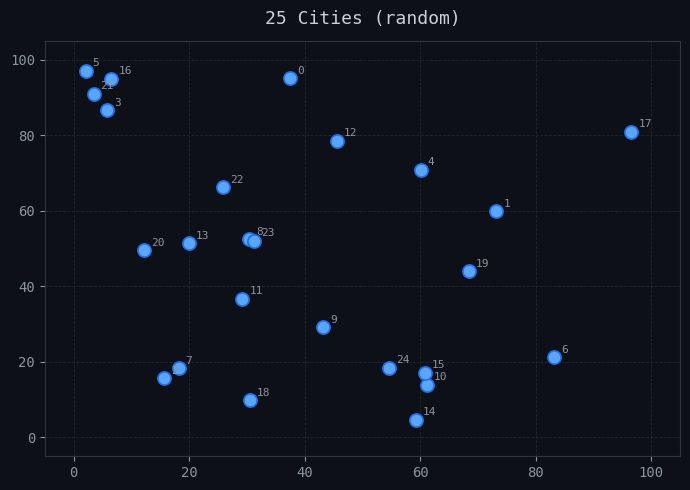

In [36]:
# ── Parameters (tweak these) ──────────────────────────────────────────────────
N_CITIES    = 25
INIT_TEMP   = 10_000
COOLING     = 0.9975
MIN_TEMP    = 0.01

# ── Generate random cities ───────────────────────────────────────────────────
cities = np.random.rand(N_CITIES, 2) * 100

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(cities[:, 0], cities[:, 1], s=90, color='#58a6ff',
           edgecolors='#1f6feb', linewidths=1.2, zorder=3)
for i, (x, y) in enumerate(cities):
    ax.text(x + 1.2, y + 1.2, str(i), fontsize=8, color='#8b949e')
ax.set_title(f'{N_CITIES} Cities (random)', color='#c9d1d9', fontsize=13, pad=12)
ax.grid(True, linestyle='--')
ax.set_xlim(-5, 105); ax.set_ylim(-5, 105)
plt.tight_layout()
plt.show()

## 2 · Core Algorithm Functions

In [37]:
def route_distance(route, cities):
    """Total Euclidean distance of a closed tour."""
    total = 0.0
    n = len(route)
    for i in range(n):
        a, b = cities[route[i]], cities[route[(i + 1) % n]]
        total += math.dist(a, b)
    return total

def two_opt_swap(route):
    """Reverse a random sub-segment (2-opt neighbourhood move)."""
    a, b = sorted(random.sample(range(len(route)), 2))
    return route[:a] + route[a:b+1][::-1] + route[b+1:]

def acceptance_probability(delta, temp):
    """Boltzmann acceptance criterion."""
    return 1.0 if delta < 0 else math.exp(-delta / temp)

print('Functions defined ✓')

Functions defined ✓


## 3 · Visualise the Acceptance Probability Curve
Higher temperature → bad moves accepted more freely.

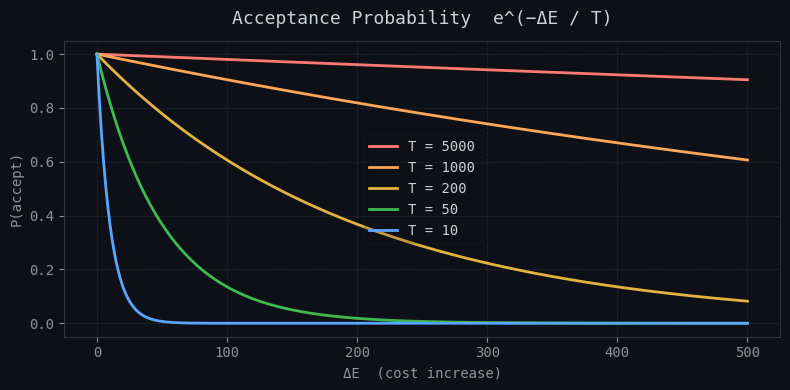

In [38]:
deltas = np.linspace(0, 500, 300)
temps  = [5000, 1000, 200, 50, 10]
colors = ['#ff7b72', '#ffa657', '#e3b341', '#3fb950', '#58a6ff']

fig, ax = plt.subplots(figsize=(8, 4))
for T, col in zip(temps, colors):
    probs = [math.exp(-d / T) for d in deltas]
    ax.plot(deltas, probs, color=col, linewidth=2, label=f'T = {T}')

ax.set_xlabel('ΔE  (cost increase)')
ax.set_ylabel('P(accept)')
ax.set_title('Acceptance Probability  e^(−ΔE / T)', color='#c9d1d9', fontsize=13, pad=12)
ax.legend(framealpha=0.15, edgecolor='#30363d')
ax.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

## 4 · Run Simulated Annealing

In [39]:
def simulated_annealing(cities, init_temp, cooling, min_temp,
                        snapshot_temps=None):
    """
    Full SA run.  Returns:
      best_route, best_cost, cost_history, temp_history, snapshots
    """
    n = len(cities)
    route = list(range(n))
    random.shuffle(route)

    cost       = route_distance(route, cities)
    best_route = route[:]
    best_cost  = cost

    temp         = init_temp
    cost_history = [cost]
    temp_history = [temp]
    snapshots    = {}          # temp → route at that moment
    snap_set     = set(snapshot_temps or [])

    while temp > min_temp:
        neighbor      = two_opt_swap(route)
        neighbor_cost = route_distance(neighbor, cities)
        delta         = neighbor_cost - cost

        if random.random() < acceptance_probability(delta, temp):
            route = neighbor
            cost  = neighbor_cost

        if cost < best_cost:
            best_cost  = cost
            best_route = route[:]

        temp *= cooling
        cost_history.append(best_cost)
        temp_history.append(temp)

        # Save snapshot at target temperatures
        for st in list(snap_set):
            if temp <= st:
                snapshots[st] = route[:]
                snap_set.discard(st)

    return best_route, best_cost, cost_history, temp_history, snapshots


snap_temps = [5000, 500, 50, 1]

best_route, best_cost, cost_history, temp_history, snapshots = simulated_annealing(
    cities, INIT_TEMP, COOLING, MIN_TEMP, snap_temps
)

print(f'Iterations : {len(cost_history):,}')
print(f'Best cost  : {best_cost:.2f}')

Iterations : 5,521
Best cost  : 415.97


## 5 · Cost & Temperature Over Time

/tmp/ipykernel_69324/2993243898.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


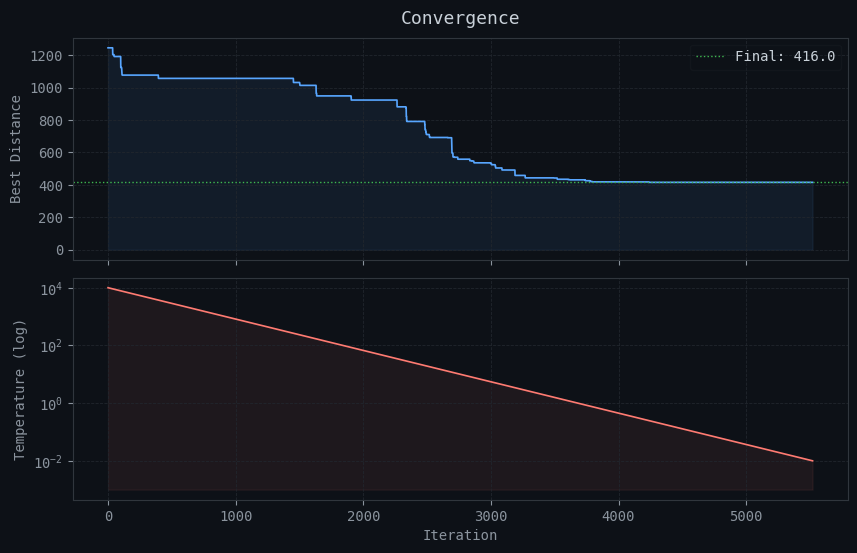

In [40]:
iters = np.arange(len(cost_history))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                                gridspec_kw={'hspace': 0.08})

# Cost
ax1.plot(iters, cost_history, color='#58a6ff', linewidth=1.2)
ax1.fill_between(iters, cost_history, alpha=0.08, color='#58a6ff')
ax1.set_ylabel('Best Distance')
ax1.set_title('Convergence', color='#c9d1d9', fontsize=13, pad=10)
ax1.grid(True, linestyle='--')
ax1.axhline(best_cost, color='#3fb950', linewidth=1,
            linestyle=':', label=f'Final: {best_cost:.1f}')
ax1.legend(framealpha=0.15, edgecolor='#30363d')

# Temperature (log)
ax2.semilogy(iters, temp_history, color='#ff7b72', linewidth=1.2)
ax2.fill_between(iters, temp_history, 1e-3, alpha=0.07, color='#ff7b72')
ax2.set_ylabel('Temperature (log)')
ax2.set_xlabel('Iteration')
ax2.grid(True, linestyle='--', which='both')

plt.tight_layout()
plt.show()

## 6 · Route Snapshots at Different Temperatures
Watch the route go from chaotic → optimised as temperature drops.

/tmp/ipykernel_69324/2387038486.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


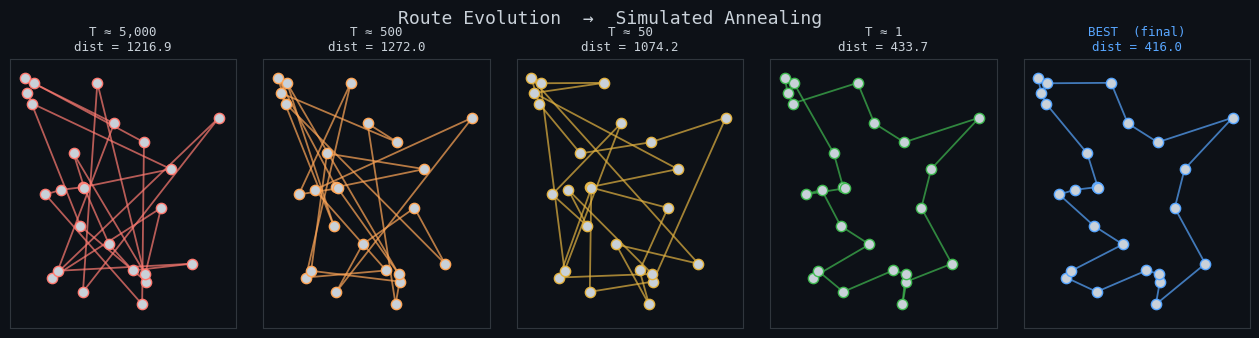

In [41]:
def draw_route(ax, route, cities, title, color='#58a6ff'):
    """Plot a TSP route on the given axes."""
    n = len(route)
    # edges
    for i in range(n):
        a, b = cities[route[i]], cities[route[(i + 1) % n]]
        ax.plot([a[0], b[0]], [a[1], b[1]], color=color,
                linewidth=1.3, alpha=0.7)
    # nodes
    ax.scatter(cities[:, 0], cities[:, 1], s=55, color='#c9d1d9',
               edgecolors=color, linewidths=1.0, zorder=3)
    d = route_distance(route, cities)
    ax.set_title(f'{title}\ndist = {d:.1f}', color='#c9d1d9', fontsize=9, pad=6)
    ax.set_xlim(-5, 105); ax.set_ylim(-5, 105)
    ax.grid(True, linestyle='--', linewidth=0.4)
    ax.set_xticks([]); ax.set_yticks([])

snap_colors = ['#ff7b72', '#ffa657', '#e3b341', '#3fb950']

fig, axes = plt.subplots(1, len(snap_temps) + 1,
                          figsize=(16, 3.5),
                          gridspec_kw={'wspace': 0.12})

# Snapshots
for ax, T, col in zip(axes, sorted(snap_temps, reverse=True), snap_colors):
    r = snapshots.get(T, best_route)
    draw_route(ax, r, cities, f'T ≈ {T:,}', color=col)

# Final best
draw_route(axes[-1], best_route, cities, 'BEST  (final)', color='#58a6ff')
axes[-1].set_title(f'BEST  (final)\ndist = {best_cost:.1f}',
                   color='#58a6ff', fontsize=9, pad=6)

fig.suptitle('Route Evolution  →  Simulated Annealing',
             color='#c9d1d9', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 7 · Heat Map of Edge Usage
Which city-to-city connections appear most often across random restarts?

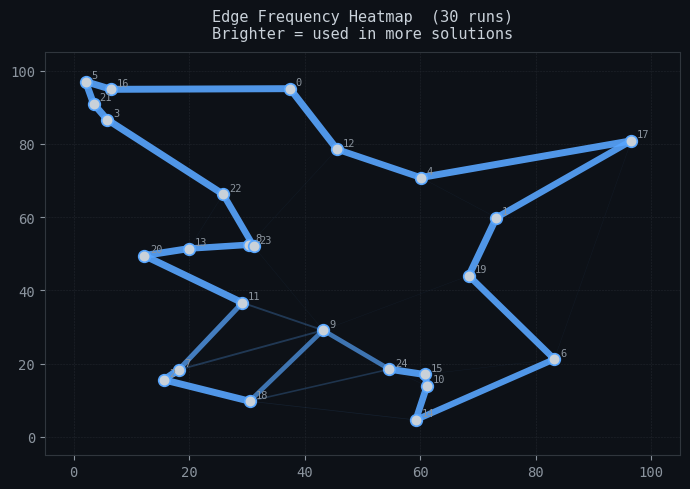

In [42]:
N_RUNS = 30
edge_count = np.zeros((N_CITIES, N_CITIES))

for _ in range(N_RUNS):
    r, _, _, _, _ = simulated_annealing(cities, INIT_TEMP, COOLING, MIN_TEMP)
    for i in range(N_CITIES):
        a, b = r[i], r[(i + 1) % N_CITIES]
        edge_count[a][b] += 1
        edge_count[b][a] += 1

# Normalise
edge_freq = edge_count / N_RUNS

fig, ax = plt.subplots(figsize=(7, 5))

# Draw all edges, width ∝ frequency
for i in range(N_CITIES):
    for j in range(i + 1, N_CITIES):
        freq = edge_freq[i][j]
        if freq > 0.05:
            ax.plot([cities[i, 0], cities[j, 0]],
                    [cities[i, 1], cities[j, 1]],
                    color='#58a6ff', alpha=min(freq, 0.9),
                    linewidth=freq * 5)

ax.scatter(cities[:, 0], cities[:, 1], s=70, color='#c9d1d9',
           edgecolors='#58a6ff', linewidths=1.2, zorder=3)
for i, (x, y) in enumerate(cities):
    ax.text(x + 1, y + 1, str(i), fontsize=7.5, color='#8b949e')

ax.set_title(f'Edge Frequency Heatmap  ({N_RUNS} runs)\n'
              'Brighter = used in more solutions',
              color='#c9d1d9', fontsize=11, pad=10)
ax.set_xlim(-5, 105); ax.set_ylim(-5, 105)
ax.grid(True, linestyle='--', linewidth=0.4)
plt.tight_layout()
plt.show()

## 8 · Effect of Cooling Rate
Slower cooling → better solutions, more iterations.

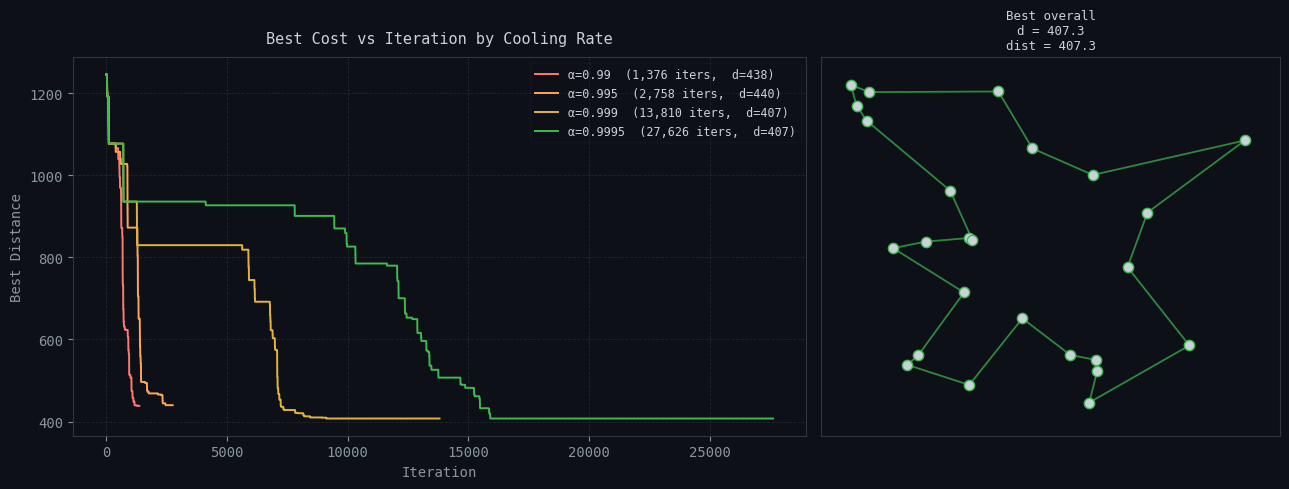

In [43]:
cooling_rates = [0.990, 0.995, 0.999, 0.9995]
colors_cr     = ['#ff7b72', '#ffa657', '#e3b341', '#3fb950']

fig, (ax_cost, ax_route) = plt.subplots(1, 2, figsize=(13, 5),
                                         gridspec_kw={'width_ratios': [1.6, 1]})

best_overall = None
best_overall_cost = math.inf

for cr, col in zip(cooling_rates, colors_cr):
    random.seed(SEED); np.random.seed(SEED)  # same start each time
    r, c, hist, _, _ = simulated_annealing(cities, INIT_TEMP, cr, MIN_TEMP)
    iters = np.arange(len(hist))
    ax_cost.plot(iters, hist, color=col, linewidth=1.4,
                 label=f'α={cr}  ({len(hist):,} iters,  d={c:.0f})')
    if c < best_overall_cost:
        best_overall_cost = c
        best_overall = r

ax_cost.set_title('Best Cost vs Iteration by Cooling Rate',
                   color='#c9d1d9', fontsize=11, pad=10)
ax_cost.set_xlabel('Iteration')
ax_cost.set_ylabel('Best Distance')
ax_cost.legend(framealpha=0.15, edgecolor='#30363d', fontsize=8.5)
ax_cost.grid(True, linestyle='--')

# Show the best route found across all cooling rates
draw_route(ax_route, best_overall, cities,
           f'Best overall\nd = {best_overall_cost:.1f}', color='#3fb950')

plt.tight_layout()
plt.show()

## 9 · Final Best Route

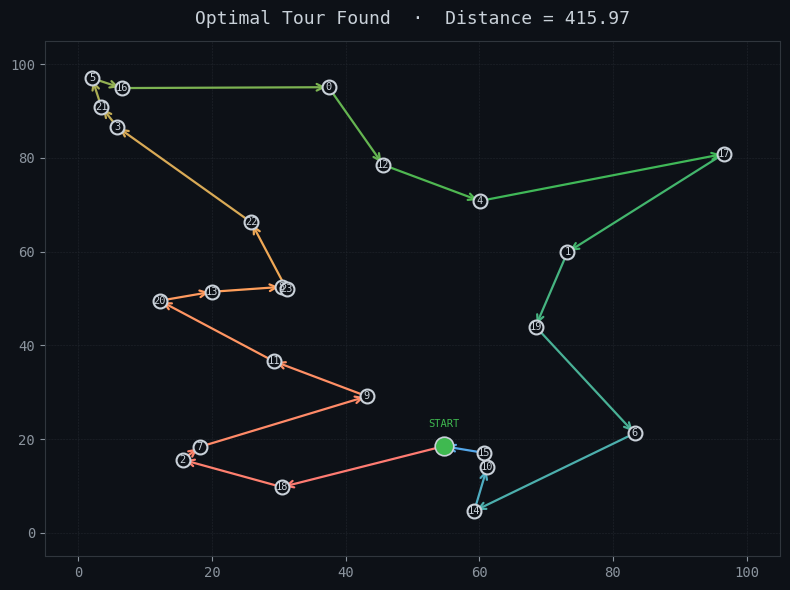

Tour order: 24 → 18 → 2 → 7 → 9 → 11 → 20 → 13 → 8 → 23 → 22 → 3 → 21 → 5 → 16 → 0 → 12 → 4 → 17 → 1 → 19 → 6 → 14 → 10 → 15 → 24


In [44]:
fig, ax = plt.subplots(figsize=(8, 6))

n = len(best_route)
# Colour edges by order in tour
cmap = LinearSegmentedColormap.from_list('tour', ['#ff7b72', '#ffa657', '#3fb950', '#58a6ff'])
for i in range(n):
    a = cities[best_route[i]]
    b = cities[best_route[(i + 1) % n]]
    col = cmap(i / n)
    ax.annotate('', xy=b, xytext=a,
                arrowprops=dict(arrowstyle='->', color=col,
                                lw=1.6, mutation_scale=12))

# Nodes
ax.scatter(cities[:, 0], cities[:, 1], s=100, color='#0d1117',
           edgecolors='#c9d1d9', linewidths=1.5, zorder=4)
for i, (x, y) in enumerate(cities):
    ax.text(x, y, str(i), ha='center', va='center',
            fontsize=7.5, color='#c9d1d9', zorder=5)

# Start city
sx, sy = cities[best_route[0]]
ax.scatter([sx], [sy], s=180, color='#3fb950', zorder=5,
           edgecolors='#c9d1d9', linewidths=1.2)
ax.text(sx, sy + 4, 'START', fontsize=7.5, color='#3fb950', ha='center')

ax.set_title(f'Optimal Tour Found  ·  Distance = {best_cost:.2f}',
              color='#c9d1d9', fontsize=13, pad=12)
ax.set_xlim(-5, 105); ax.set_ylim(-5, 105)
ax.grid(True, linestyle='--', linewidth=0.4)
plt.tight_layout()
plt.show()

print('Tour order:', ' → '.join(map(str, best_route + [best_route[0]])))